In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("everything works")

everything works


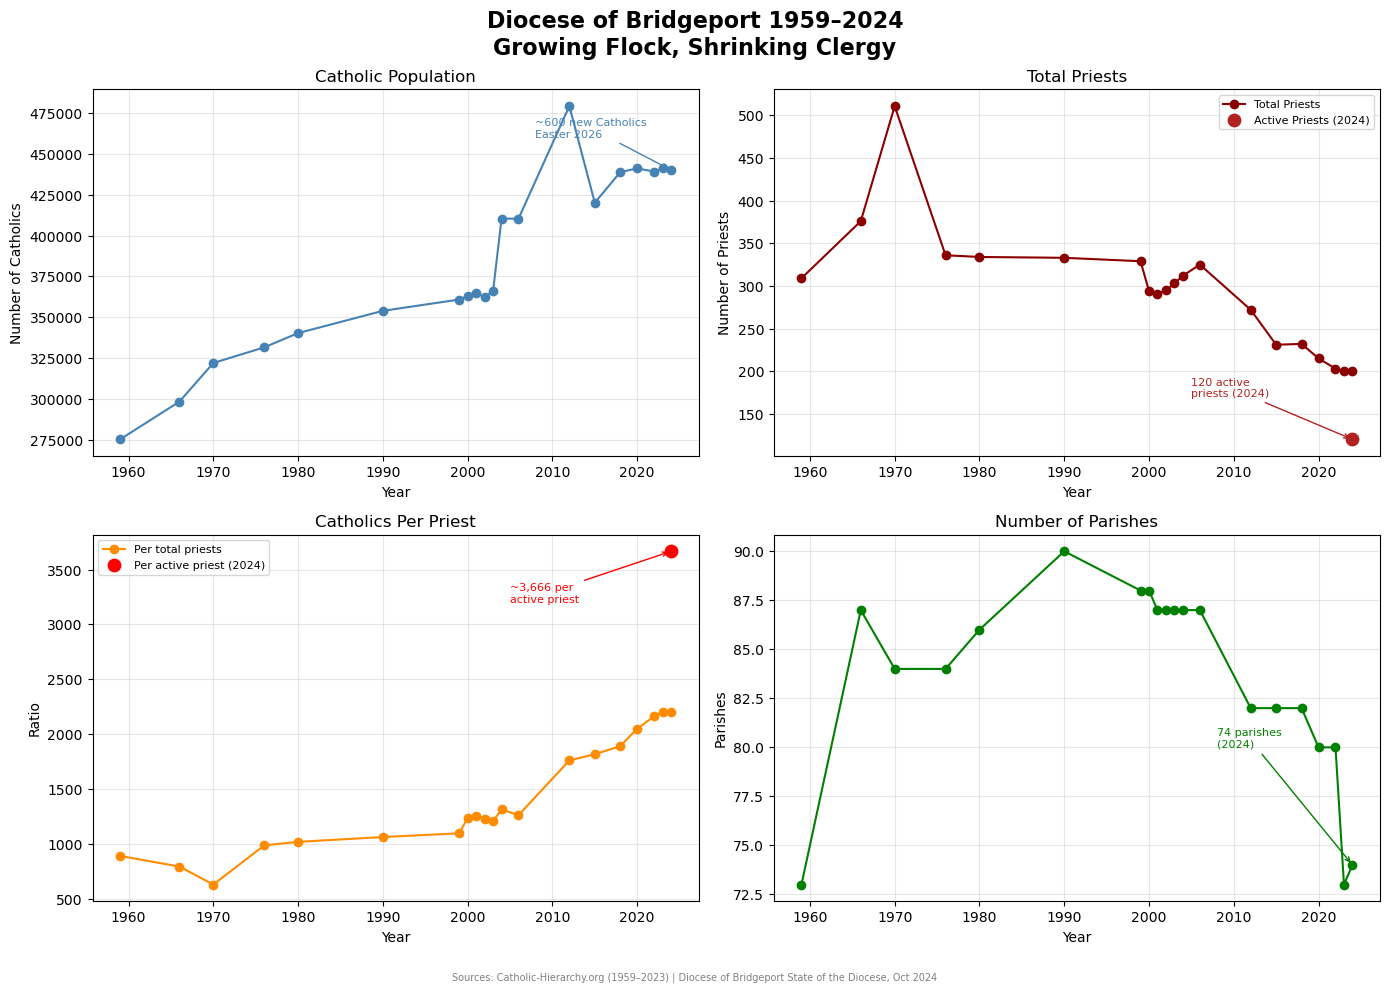

In [7]:
data = {
    'year':               [1959,1966,1970,1976,1980,1990,1999,2000,2001,2002,2003,2004,2006,2012,2015,2018,2020,2022,2023,2024],
    'catholics':          [275581,298607,322188,331734,340441,354020,360918,363246,364685,362569,365992,410304,410304,479000,420000,438664,441000,439000,441000,440000],
    'total_priests':      [309,376,511,336,334,333,329,294,291,295,303,312,325,272,231,232,215,203,200,200],
    'active_priests':     [None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,120],
    'catholics_per_priest':[891,794,630,987,1019,1063,1097,1235,1253,1229,1207,1315,1262,1761,1818,1890,2051,2162,2205,2200],
    'parishes':           [73,87,84,84,86,90,88,88,87,87,87,87,87,82,82,82,80,80,73,74],
}

df = pd.DataFrame(data)

# Catholics per ACTIVE priest for 2024
active_ratio = 440000 / 120  # ~3,667

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diocese of Bridgeport 1959–2024\nGrowing Flock, Shrinking Clergy',
             fontsize=16, fontweight='bold')

# ── Catholics ─────────────────────────────────────────────────────────────────
axes[0,0].plot(df['year'], df['catholics'], marker='o', color='steelblue')
axes[0,0].set_title('Catholic Population')
axes[0,0].set_ylabel('Number of Catholics')
axes[0,0].annotate('~600 new Catholics\nEaster 2026',
                   xy=(2024, 440000), xytext=(2008, 460000),
                   arrowprops=dict(arrowstyle='->', color='steelblue'),
                   fontsize=8, color='steelblue')

# ── Total Priests ─────────────────────────────────────────────────────────────
axes[0,1].plot(df['year'], df['total_priests'], marker='o', color='darkred',
               label='Total Priests')
axes[0,1].scatter([2024], [120], color='firebrick', zorder=5, s=80,
                  label='Active Priests (2024)')
axes[0,1].annotate('120 active\npriests (2024)',
                   xy=(2024, 120), xytext=(2005, 170),
                   arrowprops=dict(arrowstyle='->', color='firebrick'),
                   fontsize=8, color='firebrick')
axes[0,1].set_title('Total Priests')
axes[0,1].set_ylabel('Number of Priests')
axes[0,1].legend(fontsize=8)

# ── Catholics Per Priest ──────────────────────────────────────────────────────
axes[1,0].plot(df['year'], df['catholics_per_priest'], marker='o', color='darkorange',
               label='Per total priests')
axes[1,0].scatter([2024], [active_ratio], color='red', zorder=5, s=80,
                  label='Per active priest (2024)')
axes[1,0].annotate(f'~{int(active_ratio):,} per\nactive priest',
                   xy=(2024, active_ratio), xytext=(2005, 3200),
                   arrowprops=dict(arrowstyle='->', color='red'),
                   fontsize=8, color='red')
axes[1,0].set_title('Catholics Per Priest')
axes[1,0].set_ylabel('Ratio')
axes[1,0].legend(fontsize=8)

# ── Parishes ──────────────────────────────────────────────────────────────────
axes[1,1].plot(df['year'], df['parishes'], marker='o', color='green')
axes[1,1].set_title('Number of Parishes')
axes[1,1].set_ylabel('Parishes')
axes[1,1].annotate('74 parishes\n(2024)',
                   xy=(2024, 74), xytext=(2008, 80),
                   arrowprops=dict(arrowstyle='->', color='green'),
                   fontsize=8, color='green')

# ── Shared formatting ─────────────────────────────────────────────────────────
for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

fig.text(0.5, 0.01,
         'Sources: Catholic-Hierarchy.org (1959–2023) | Diocese of Bridgeport State of the Diocese, Oct 2024',
         ha='center', fontsize=7, color='gray')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

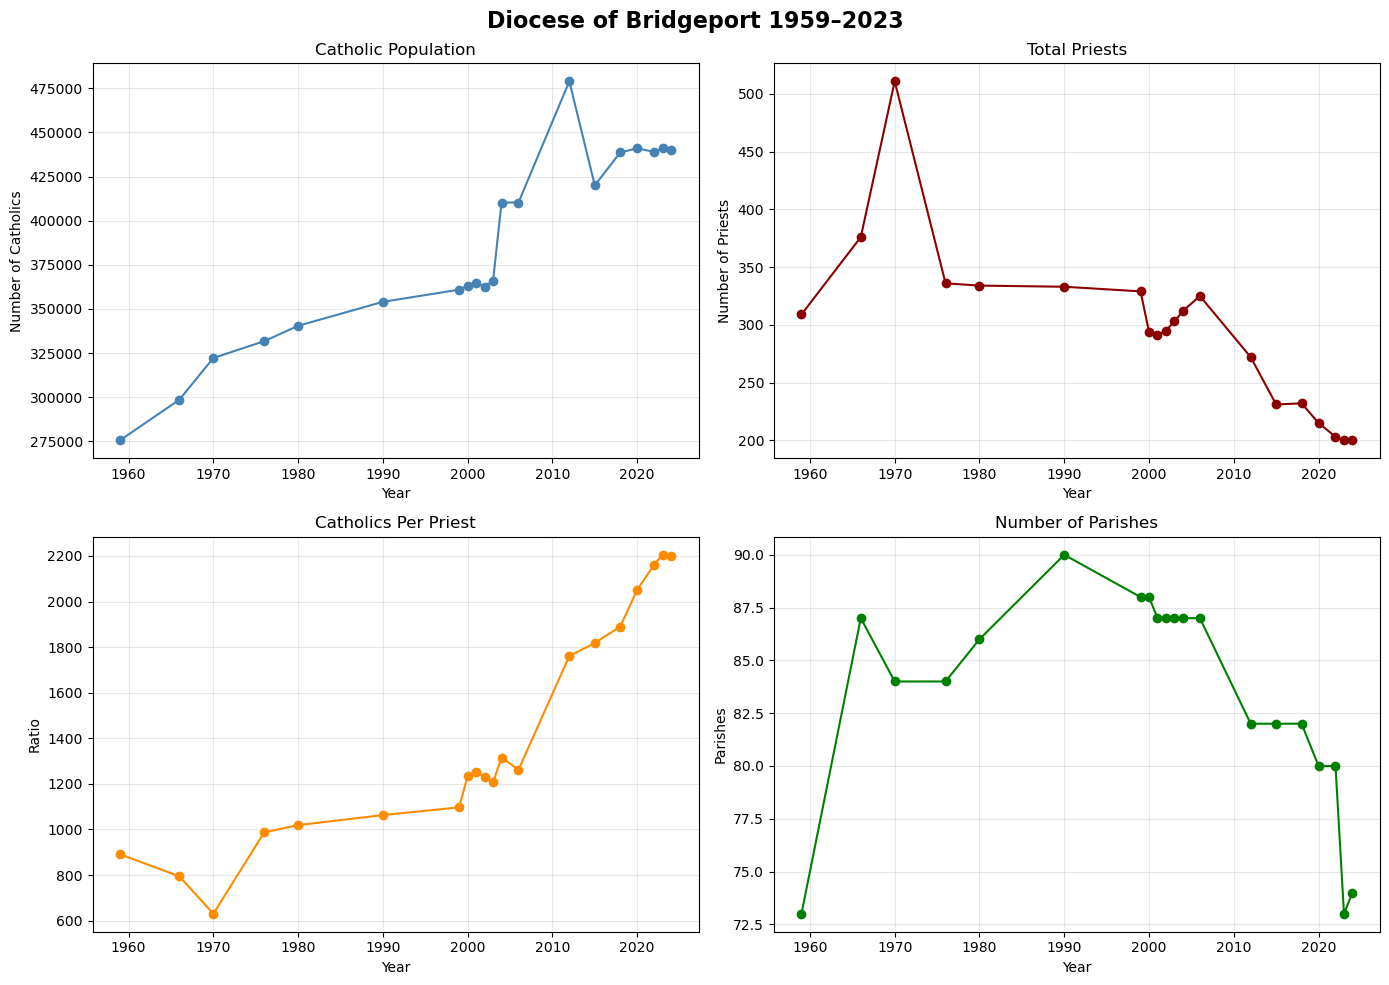

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diocese of Bridgeport 1959–2023', fontsize=16, fontweight='bold')

# Catholics over time
axes[0,0].plot(df['year'], df['catholics'], marker='o', color='steelblue')
axes[0,0].set_title('Catholic Population')
axes[0,0].set_ylabel('Number of Catholics')

# Total priests over time
axes[0,1].plot(df['year'], df['total_priests'], marker='o', color='darkred')
axes[0,1].set_title('Total Priests')
axes[0,1].set_ylabel('Number of Priests')

# Catholics per priest over time
axes[1,0].plot(df['year'], df['catholics_per_priest'], marker='o', color='darkorange')
axes[1,0].set_title('Catholics Per Priest')
axes[1,0].set_ylabel('Ratio')

# Parishes over time
axes[1,1].plot(df['year'], df['parishes'], marker='o', color='green')
axes[1,1].set_title('Number of Parishes')
axes[1,1].set_ylabel('Parishes')

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# How much has each metric changed from 1959 to 2023?
start = df[df['year'] == 1959].iloc[0]
end = df[df['year'] == 2023].iloc[0]

metrics = ['catholics', 'total_priests', 'parishes', 'catholics_per_priest']
for m in metrics:
    change = ((end[m] - start[m]) / start[m]) * 100
    print(f"{m}: {change:+.1f}%")

catholics: +60.0%
total_priests: -35.3%
parishes: +0.0%
catholics_per_priest: +147.5%


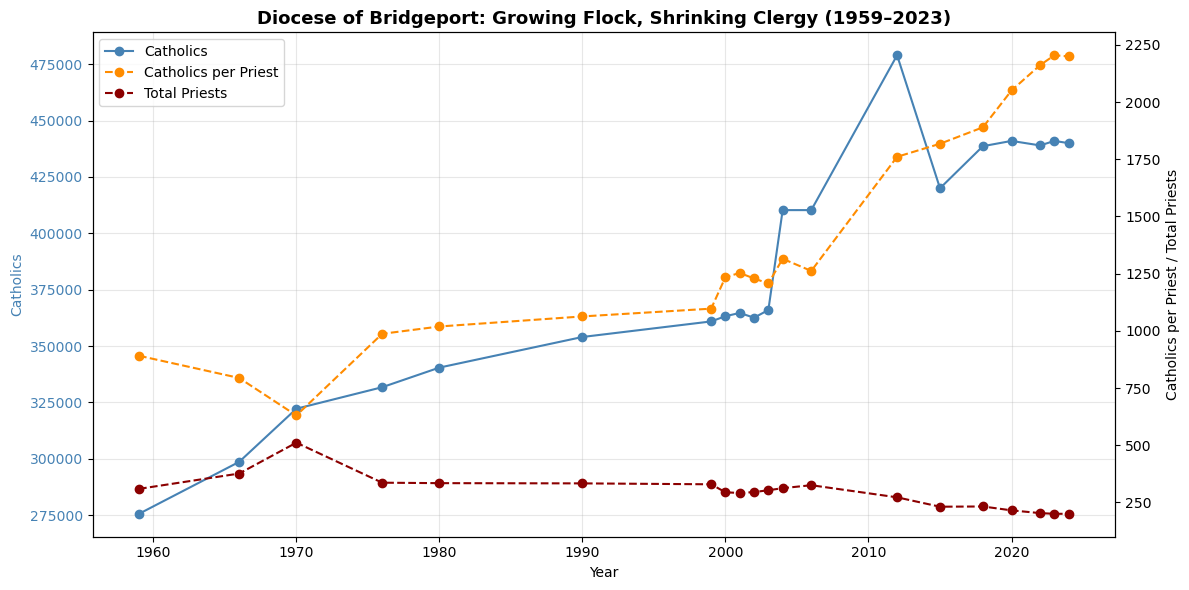

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis - Catholics
ax1.set_xlabel('Year')
ax1.set_ylabel('Catholics', color='steelblue')
ax1.plot(df['year'], df['catholics'], marker='o', color='steelblue', label='Catholics')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Right axis 1 - Catholics per priest
ax2 = ax1.twinx()
ax2.set_ylabel('Catholics per Priest / Total Priests', color='black')
ax2.plot(df['year'], df['catholics_per_priest'], marker='o', color='darkorange',
         linestyle='--', label='Catholics per Priest')
ax2.plot(df['year'], df['total_priests'], marker='o', color='darkred',
         linestyle='--', label='Total Priests')
ax2.tick_params(axis='y')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Diocese of Bridgeport: Growing Flock, Shrinking Clergy (1959–2023)',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## We are going to clean here again

In [12]:
data = {
    'year':                [1959,1966,1970,1976,1980,1990,1999,2000,2001,2002,2003,2004,2006,2012,2015,2018,2020,2022,2023,2024],
    'catholics':           [275581,298607,322188,331734,340441,354020,360918,363246,364685,362569,365992,410304,410304,479000,420000,438664,441000,439000,441000,440000],
    'total_priests':       [309,376,511,336,334,333,329,294,291,295,303,312,325,272,231,232,215,203,200,200],
    'catholics_per_priest':[891,794,630,987,1019,1063,1097,1235,1253,1229,1207,1315,1262,1761,1818,1890,2051,2162,2205,2200],
    'parishes':            [73,87,84,84,86,90,88,88,87,87,87,87,87,82,82,82,80,80,73,74],
}

df = pd.DataFrame(data)
active_ratio = round(440000 / 120)  # 3,667
print("Data loaded successfully")
print(df.to_string())

Data loaded successfully
    year  catholics  total_priests  catholics_per_priest  parishes
0   1959     275581            309                   891        73
1   1966     298607            376                   794        87
2   1970     322188            511                   630        84
3   1976     331734            336                   987        84
4   1980     340441            334                  1019        86
5   1990     354020            333                  1063        90
6   1999     360918            329                  1097        88
7   2000     363246            294                  1235        88
8   2001     364685            291                  1253        87
9   2002     362569            295                  1229        87
10  2003     365992            303                  1207        87
11  2004     410304            312                  1315        87
12  2006     410304            325                  1262        87
13  2012     479000            272   

## Cell 2 — Four-Panel Chart (updated 2024 version)

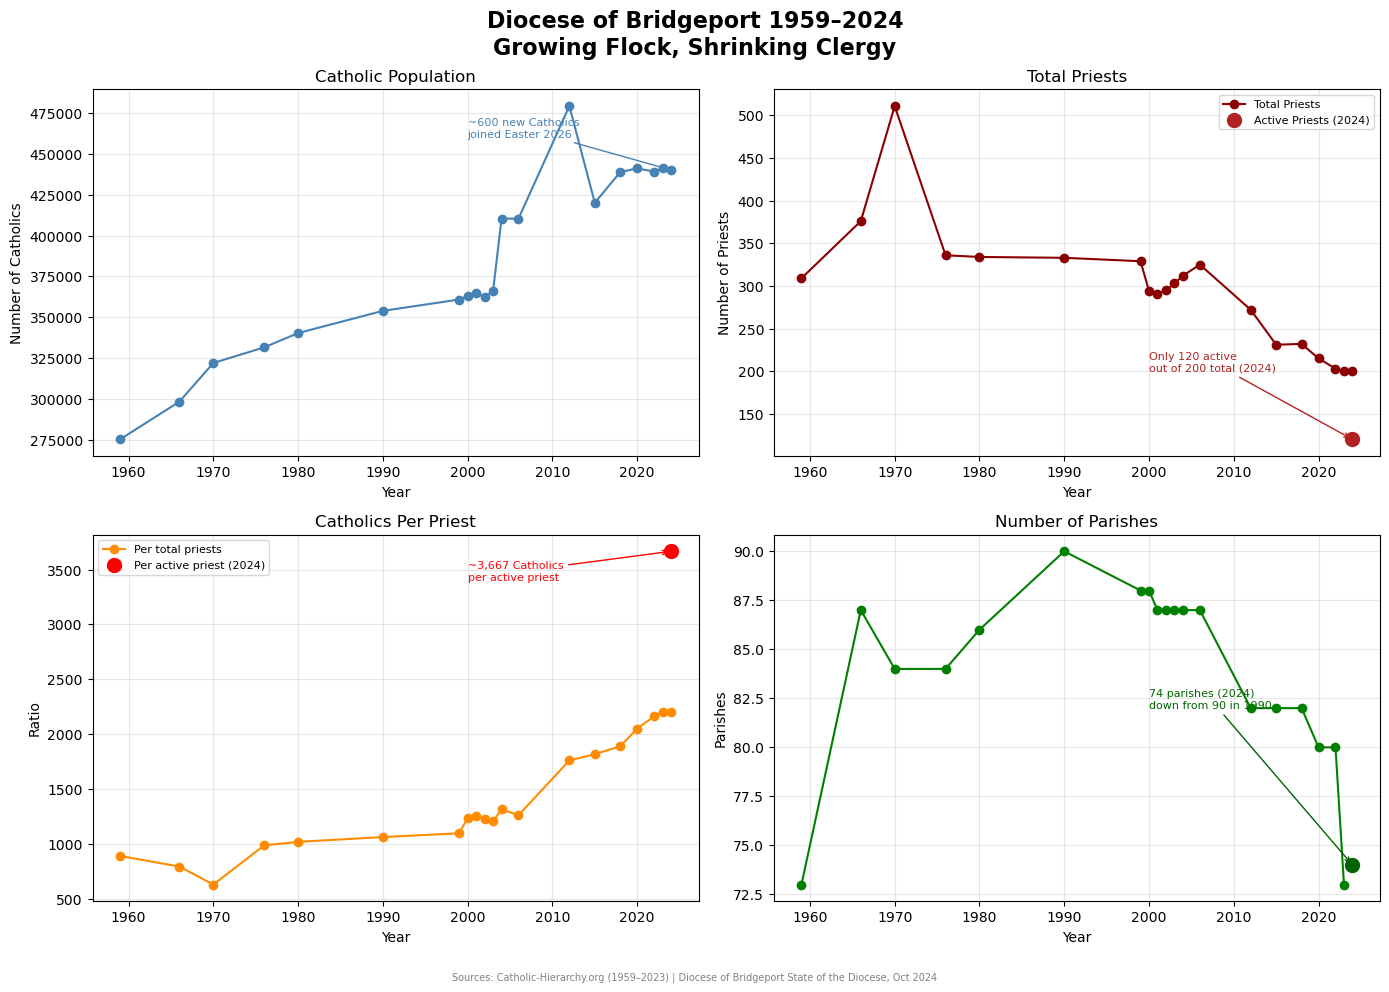

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diocese of Bridgeport 1959–2024\nGrowing Flock, Shrinking Clergy',
             fontsize=16, fontweight='bold')

# ── Catholics ─────────────────────────────────────────────────────────────────
axes[0,0].plot(df['year'], df['catholics'], marker='o', color='steelblue')
axes[0,0].set_title('Catholic Population')
axes[0,0].set_ylabel('Number of Catholics')
axes[0,0].annotate('~600 new Catholics\njoined Easter 2026',
                   xy=(2024, 440000),
                   xytext=(2000, 460000),
                   arrowprops=dict(arrowstyle='->', color='steelblue'),
                   fontsize=8, color='steelblue')

# ── Total Priests ─────────────────────────────────────────────────────────────
axes[0,1].plot(df['year'], df['total_priests'], marker='o', color='darkred',
               label='Total Priests')
axes[0,1].scatter([2024], [120], color='firebrick', zorder=5, s=100,
                  label='Active Priests (2024)')
axes[0,1].annotate('Only 120 active\nout of 200 total (2024)',
                   xy=(2024, 120),
                   xytext=(2000, 200),
                   arrowprops=dict(arrowstyle='->', color='firebrick'),
                   fontsize=8, color='firebrick')
axes[0,1].set_title('Total Priests')
axes[0,1].set_ylabel('Number of Priests')
axes[0,1].legend(fontsize=8)

# ── Catholics Per Priest ──────────────────────────────────────────────────────
axes[1,0].plot(df['year'], df['catholics_per_priest'], marker='o', color='darkorange',
               label='Per total priests')
axes[1,0].scatter([2024], [active_ratio], color='red', zorder=5, s=100,
                  label='Per active priest (2024)')
axes[1,0].annotate(f'~{active_ratio:,} Catholics\nper active priest',
                   xy=(2024, active_ratio),
                   xytext=(2000, 3400),
                   arrowprops=dict(arrowstyle='->', color='red'),
                   fontsize=8, color='red')
axes[1,0].set_title('Catholics Per Priest')
axes[1,0].set_ylabel('Ratio')
axes[1,0].legend(fontsize=8)

# ── Parishes ──────────────────────────────────────────────────────────────────
df_line = df[df['year'] <= 2023]
axes[1,1].plot(df_line['year'], df_line['parishes'], marker='o', color='green')
axes[1,1].scatter([2024], [74], color='darkgreen', zorder=5, s=100)
axes[1,1].annotate('74 parishes (2024)\ndown from 90 in 1990',
                   xy=(2024, 74),
                   xytext=(2000, 82),
                   arrowprops=dict(arrowstyle='->', color='darkgreen'),
                   fontsize=8, color='darkgreen')
axes[1,1].set_title('Number of Parishes')
axes[1,1].set_ylabel('Parishes')

# ── Shared formatting ─────────────────────────────────────────────────────────
for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

fig.text(0.5, 0.01,
         'Sources: Catholic-Hierarchy.org (1959–2023) | Diocese of Bridgeport State of the Diocese, Oct 2024',
         ha='center', fontsize=7, color='gray')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 2a — Catholic Population

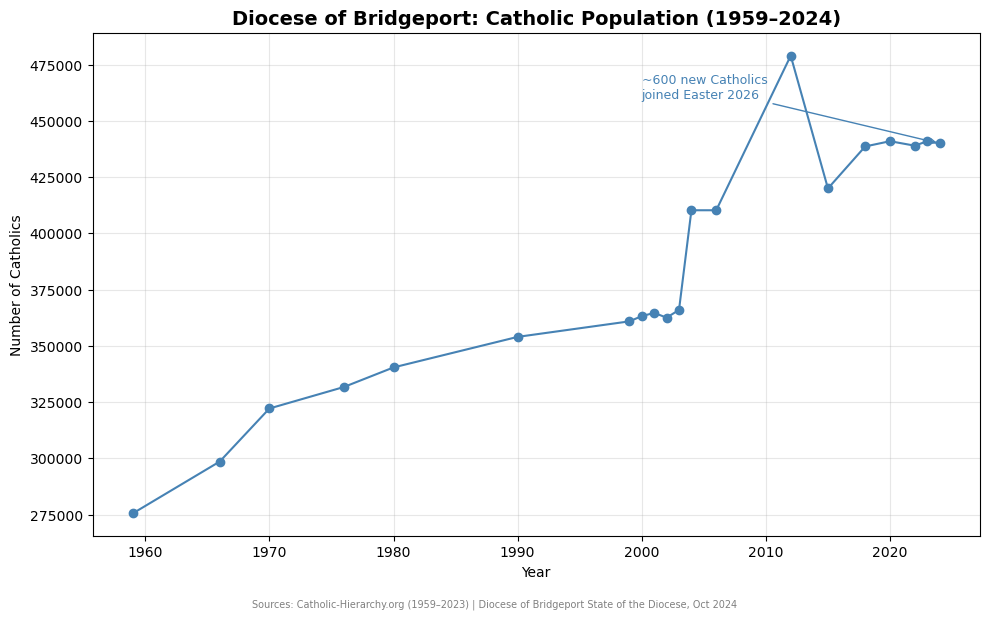

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['year'], df['catholics'], marker='o', color='steelblue')
ax.set_title('Diocese of Bridgeport: Catholic Population (1959–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Catholics')
ax.set_xlabel('Year')
ax.annotate('~600 new Catholics\njoined Easter 2026',
            xy=(2024, 440000),
            xytext=(2000, 460000),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            fontsize=9, color='steelblue')
ax.grid(True, alpha=0.3)
fig.text(0.5, -0.02,
         'Sources: Catholic-Hierarchy.org (1959–2023) | Diocese of Bridgeport State of the Diocese, Oct 2024',
         ha='center', fontsize=7, color='gray')
plt.tight_layout()
plt.show()

## 2b — Total Priests

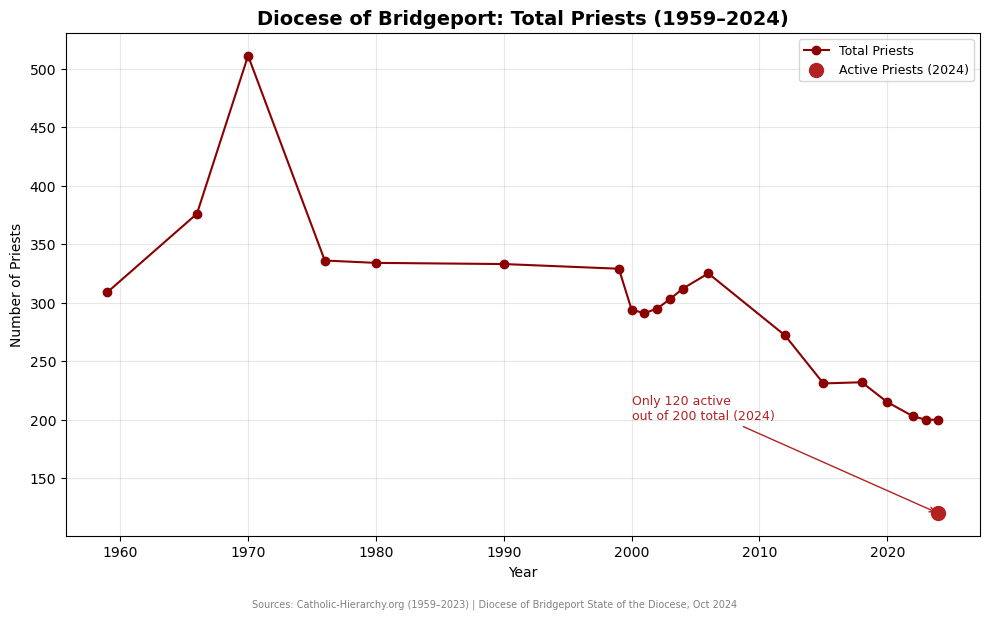

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['year'], df['total_priests'], marker='o', color='darkred',
        label='Total Priests')
ax.scatter([2024], [120], color='firebrick', zorder=5, s=100,
           label='Active Priests (2024)')
ax.annotate('Only 120 active\nout of 200 total (2024)',
            xy=(2024, 120),
            xytext=(2000, 200),
            arrowprops=dict(arrowstyle='->', color='firebrick'),
            fontsize=9, color='firebrick')
ax.set_title('Diocese of Bridgeport: Total Priests (1959–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Priests')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.text(0.5, -0.02,
         'Sources: Catholic-Hierarchy.org (1959–2023) | Diocese of Bridgeport State of the Diocese, Oct 2024',
         ha='center', fontsize=7, color='gray')
plt.tight_layout()
plt.show()

## 2c — Catholics Per Priest

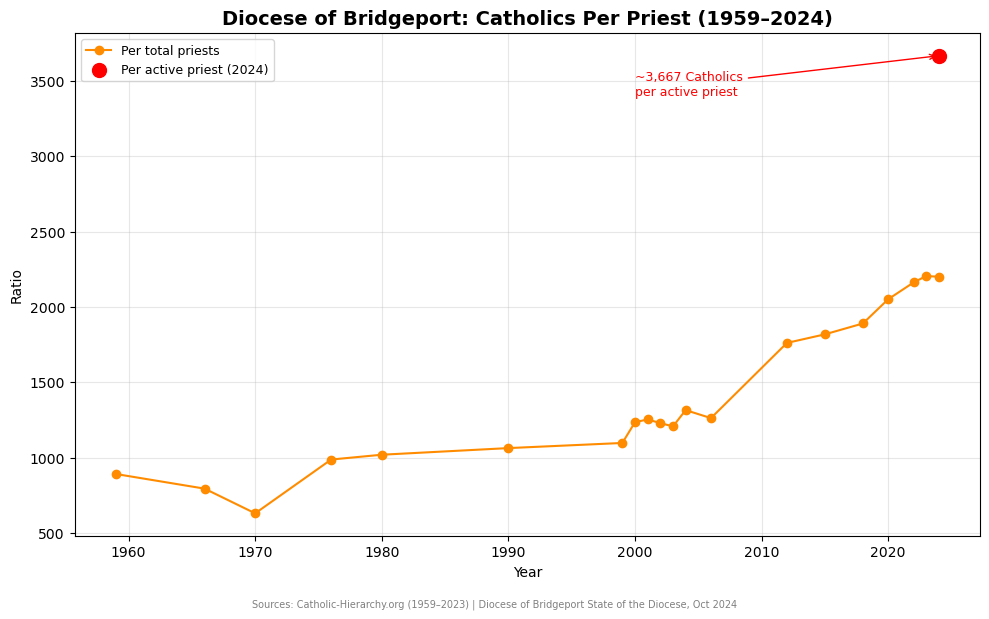

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['year'], df['catholics_per_priest'], marker='o', color='darkorange',
        label='Per total priests')
ax.scatter([2024], [active_ratio], color='red', zorder=5, s=100,
           label='Per active priest (2024)')
ax.annotate(f'~{active_ratio:,} Catholics\nper active priest',
            xy=(2024, active_ratio),
            xytext=(2000, 3400),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')
ax.set_title('Diocese of Bridgeport: Catholics Per Priest (1959–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Ratio')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.text(0.5, -0.02,
         'Sources: Catholic-Hierarchy.org (1959–2023) | Diocese of Bridgeport State of the Diocese, Oct 2024',
         ha='center', fontsize=7, color='gray')
plt.tight_layout()
plt.show()

## 2d — Number of Parishes

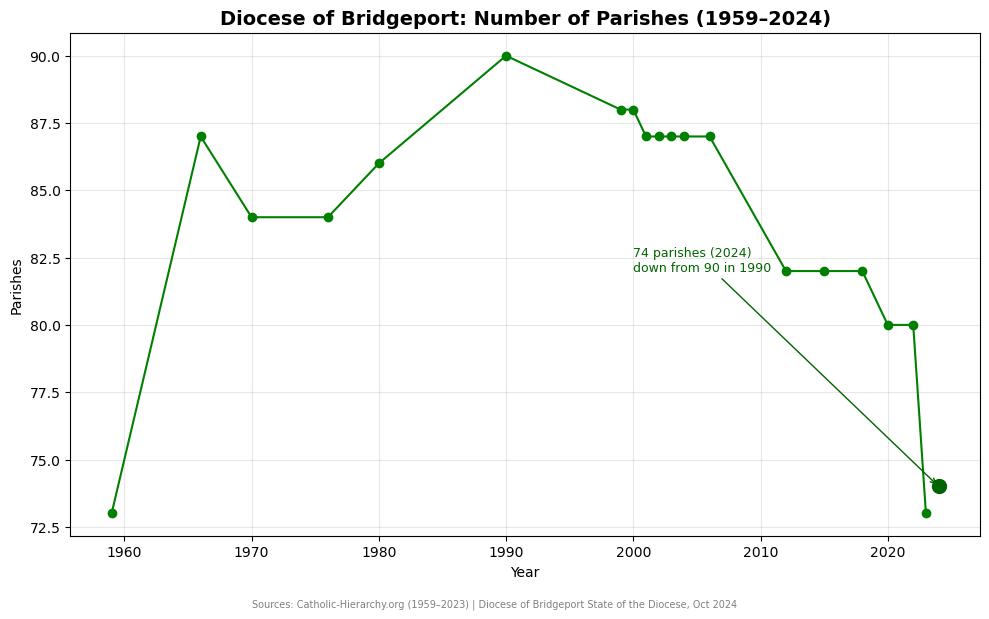

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

df_line = df[df['year'] <= 2023]
ax.plot(df_line['year'], df_line['parishes'], marker='o', color='green')
ax.scatter([2024], [74], color='darkgreen', zorder=5, s=100)
ax.annotate('74 parishes (2024)\ndown from 90 in 1990',
            xy=(2024, 74),
            xytext=(2000, 82),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=9, color='darkgreen')
ax.set_title('Diocese of Bridgeport: Number of Parishes (1959–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Parishes')
ax.set_xlabel('Year')
ax.grid(True, alpha=0.3)
fig.text(0.5, -0.02,
         'Sources: Catholic-Hierarchy.org (1959–2023) | Diocese of Bridgeport State of the Diocese, Oct 2024',
         ha='center', fontsize=7, color='gray')
plt.tight_layout()
plt.show()

## Single Combined Line Chart (the "Growing Flock" version)

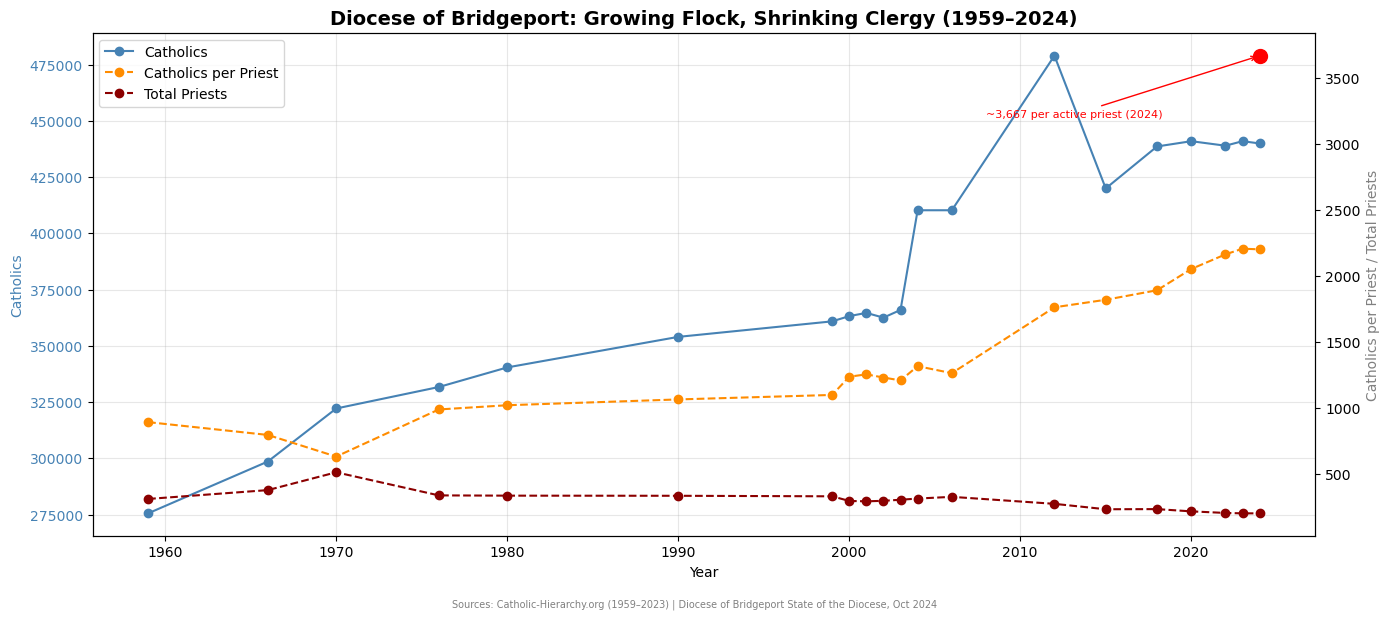

In [14]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()

ax1.plot(df['year'], df['catholics'], marker='o', color='steelblue', label='Catholics')
ax2.plot(df['year'], df['catholics_per_priest'], marker='o', linestyle='--',
         color='darkorange', label='Catholics per Priest')
ax2.plot(df['year'], df['total_priests'], marker='o', linestyle='--',
         color='darkred', label='Total Priests')

# Annotate active priest ratio
ax2.scatter([2024], [active_ratio], color='red', zorder=5, s=100)
ax2.annotate(f'~{active_ratio:,} per active priest (2024)',
             xy=(2024, active_ratio),
             xytext=(2008, 3200),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=8, color='red')

ax1.set_xlabel('Year')
ax1.set_ylabel('Catholics', color='steelblue')
ax2.set_ylabel('Catholics per Priest / Total Priests', color='gray')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Diocese of Bridgeport: Growing Flock, Shrinking Clergy (1959–2024)',
          fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         'Sources: Catholic-Hierarchy.org (1959–2023) | Diocese of Bridgeport State of the Diocese, Oct 2024',
         ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.show()